# Investigation: Why Do Models Fail on FinARG and AEC?

## Research Question
FinARG and AEC consistently show the lowest performance across all models and context conditions. This notebook investigates potential causes:

1. **Class bias**: Do models systematically prefer one class?
2. **Domain characteristics**: Are the sentences fundamentally different?
3. **Definition mismatch**: Do the extracted definitions align with the actual annotation?
4. **Text complexity**: Are these datasets harder linguistically?

## Hypothesis
The poor performance could be a **scientific finding** about:
- Cross-domain generalization limits
- Definition interpretability issues
- Dataset-specific annotation artifacts

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import re

# Load experiment results
output_dir = Path('.')
results = {}

for json_file in sorted(output_dir.glob('*.json')):
    with open(json_file) as f:
        data = json.load(f)
        experiment_id = json_file.stem
        results[experiment_id] = data

print(f"Loaded {len(results)} experiments")

# Focus on baseline experiments for comparison
baseline_results = {k: v for k, v in results.items() if 'baseline' in k}

Loaded 10 experiments


## 1. Performance Overview: FinARG vs AEC vs Other Datasets

In [2]:
# Extract F1 scores for all datasets across baseline models
all_datasets = ['ABSTRCT', 'ACQUA', 'AEC', 'AFS', 'ARGUMINSCI', 'FINARG', 'IAM', 'PE', 'SCIARK', 'USELEC']

# Aggregate F1 scores across all baseline models
dataset_f1_scores = {ds: [] for ds in all_datasets}

for model_id, model_data in baseline_results.items():
    for dataset in all_datasets:
        if dataset in model_data['datasets']:
            f1 = model_data['datasets'][dataset]['reports']['original']['macro avg']['f1-score']
            dataset_f1_scores[dataset].append(f1)

# Calculate statistics
dataset_stats = pd.DataFrame({
    'Dataset': all_datasets,
    'Mean F1': [np.mean(dataset_f1_scores[ds]) for ds in all_datasets],
    'Std F1': [np.std(dataset_f1_scores[ds]) for ds in all_datasets],
    'Min F1': [np.min(dataset_f1_scores[ds]) for ds in all_datasets],
    'Max F1': [np.max(dataset_f1_scores[ds]) for ds in all_datasets],
    'N_models': [len(dataset_f1_scores[ds]) for ds in all_datasets]
})

dataset_stats = dataset_stats.sort_values('Mean F1')
print("\n=== Dataset Performance Ranking (Baseline Models) ===")
print(dataset_stats.to_string(index=False))

# Highlight FinARG and AEC
print("\n🔴 Bottom 3 datasets:")
print(dataset_stats.head(3).to_string(index=False))


=== Dataset Performance Ranking (Baseline Models) ===
   Dataset  Mean F1   Std F1   Min F1   Max F1  N_models
    FINARG 0.449646 0.042601 0.403409 0.499358         5
       AEC 0.485920 0.086486 0.401709 0.632925         5
        PE 0.548928 0.140003 0.384405 0.728507         5
    SCIARK 0.556236 0.049107 0.499358 0.632925         5
ARGUMINSCI 0.617750 0.091620 0.475000 0.764310         5
       IAM 0.625275 0.082183 0.466484 0.699666         5
       AFS 0.652250 0.129303 0.403409 0.760000         5
   ABSTRCT 0.687206 0.055082 0.622857 0.760000         5
    USELEC 0.701471 0.100067 0.523810 0.833148         5
     ACQUA 0.706869 0.072180 0.612221 0.766407         5

🔴 Bottom 3 datasets:
Dataset  Mean F1   Std F1   Min F1   Max F1  N_models
 FINARG 0.449646 0.042601 0.403409 0.499358         5
    AEC 0.485920 0.086486 0.401709 0.632925         5
     PE 0.548928 0.140003 0.384405 0.728507         5


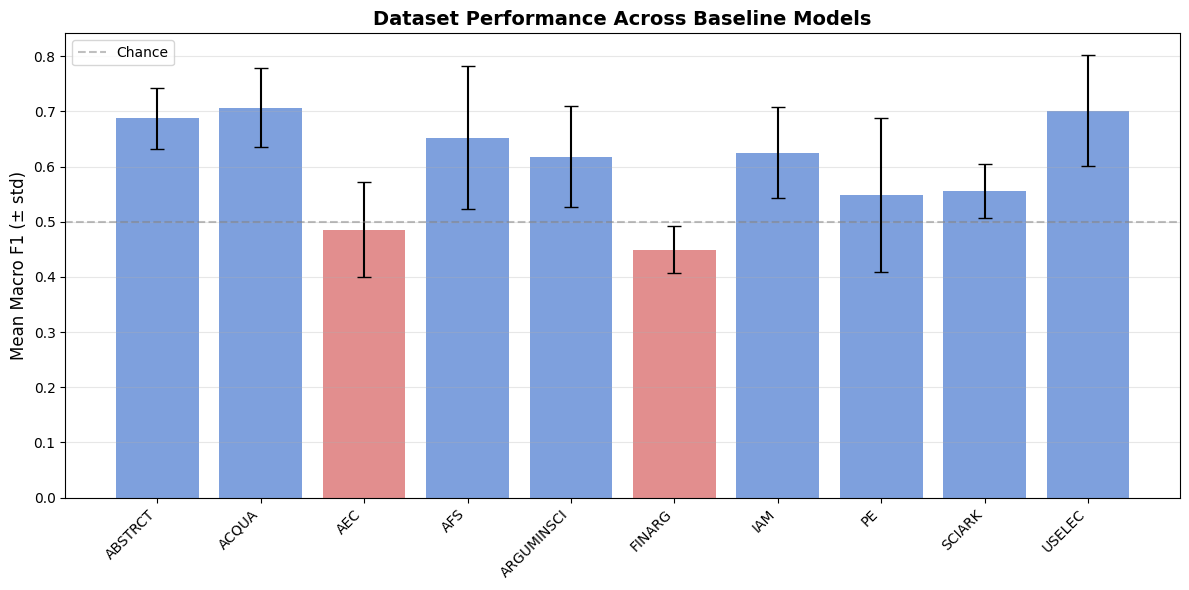

🔴 Red = FinARG & AEC (target datasets)
🔵 Blue = Other datasets


In [3]:
# Visualize F1 distribution
fig, ax = plt.subplots(figsize=(12, 6))

positions = np.arange(len(all_datasets))
means = [np.mean(dataset_f1_scores[ds]) for ds in all_datasets]
stds = [np.std(dataset_f1_scores[ds]) for ds in all_datasets]

colors = ['#D65F5F' if ds in ['FINARG', 'AEC'] else '#4878CF' for ds in all_datasets]

ax.bar(positions, means, yerr=stds, color=colors, alpha=0.7, capsize=5)
ax.set_xticks(positions)
ax.set_xticklabels(all_datasets, rotation=45, ha='right')
ax.set_ylabel('Mean Macro F1 (± std)', fontsize=12)
ax.set_title('Dataset Performance Across Baseline Models', fontsize=14, fontweight='bold')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax.grid(axis='y', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print("🔴 Red = FinARG & AEC (target datasets)")
print("🔵 Blue = Other datasets")

## 2. Class-Level Analysis: Massive Prediction Bias?

In [4]:
# Extract per-class metrics for FinARG and AEC across all baseline models
def extract_class_metrics(dataset_name):
    """Extract precision/recall for both classes across all baseline models."""
    metrics = []
    
    for model_id, model_data in baseline_results.items():
        if dataset_name not in model_data['datasets']:
            continue
        
        # Extract model name
        if 'gpt-4' in model_id:
            model_name = 'GPT-4.1'
        elif 'Mistral-Small-24B' in model_id:
            model_name = 'Mistral-24B'
        elif 'Meta-Llama-3_1-70B' in model_id:
            model_name = 'Llama-70B'
        elif 'Meta-Llama-3_1-8B' in model_id:
            model_name = 'Llama-8B'
        elif 'Mistral-7B' in model_id:
            model_name = 'Mistral-7B'
        else:
            model_name = model_id
        
        report = model_data['datasets'][dataset_name]['reports']['original']
        
        metrics.append({
            'Model': model_name,
            'Arg_Precision': report.get('Argument', {}).get('precision', 0),
            'Arg_Recall': report.get('Argument', {}).get('recall', 0),
            'Arg_F1': report.get('Argument', {}).get('f1-score', 0),
            'NoArg_Precision': report.get('No-Argument', {}).get('precision', 0),
            'NoArg_Recall': report.get('No-Argument', {}).get('recall', 0),
            'NoArg_F1': report.get('No-Argument', {}).get('f1-score', 0),
            'Accuracy': report['accuracy'],
            'Macro_F1': report['macro avg']['f1-score']
        })
    
    return pd.DataFrame(metrics)

# Extract for FinARG and AEC
finarg_metrics = extract_class_metrics('FINARG')
aec_metrics = extract_class_metrics('AEC')

print("\n" + "="*80)
print("=== FinARG: Per-Class Performance ===")
print("="*80)
print(finarg_metrics.round(3).to_string(index=False))

print("\n" + "="*80)
print("=== AEC: Per-Class Performance ===")
print("="*80)
print(aec_metrics.round(3).to_string(index=False))

# Calculate recall gap (No-Arg recall - Arg recall)
finarg_metrics['Recall_Gap'] = finarg_metrics['NoArg_Recall'] - finarg_metrics['Arg_Recall']
aec_metrics['Recall_Gap'] = aec_metrics['NoArg_Recall'] - aec_metrics['Arg_Recall']

print("\n⚠️  CRITICAL FINDING: Recall Gap (NoArg - Arg)")
print("   Positive gap = model favors predicting 'No-Argument'\n")
print("FinARG recall gaps:")
print(finarg_metrics[['Model', 'Recall_Gap']].round(3).to_string(index=False))
print(f"\nMean recall gap: {finarg_metrics['Recall_Gap'].mean():.3f}")

print("\nAEC recall gaps:")
print(aec_metrics[['Model', 'Recall_Gap']].round(3).to_string(index=False))
print(f"\nMean recall gap: {aec_metrics['Recall_Gap'].mean():.3f}")


=== FinARG: Per-Class Performance ===
      Model  Arg_Precision  Arg_Recall  Arg_F1  NoArg_Precision  NoArg_Recall  NoArg_F1  Accuracy  Macro_F1
    GPT-4.1          0.750       0.200   0.316            0.538         0.933     0.683     0.567     0.499
  Llama-70B          0.667       0.133   0.222            0.519         0.933     0.667     0.533     0.444
   Llama-8B          0.522       0.800   0.632            0.571         0.267     0.364     0.533     0.498
 Mistral-7B          1.000       0.067   0.125            0.517         1.000     0.682     0.533     0.403
Mistral-24B          1.000       0.067   0.125            0.517         1.000     0.682     0.533     0.403

=== AEC: Per-Class Performance ===
      Model  Arg_Precision  Arg_Recall  Arg_F1  NoArg_Precision  NoArg_Recall  NoArg_F1  Accuracy  Macro_F1
    GPT-4.1          0.611       0.733   0.667            0.636         0.467     0.538     0.600     0.402
  Llama-70B          0.526       0.667   0.588            0.5

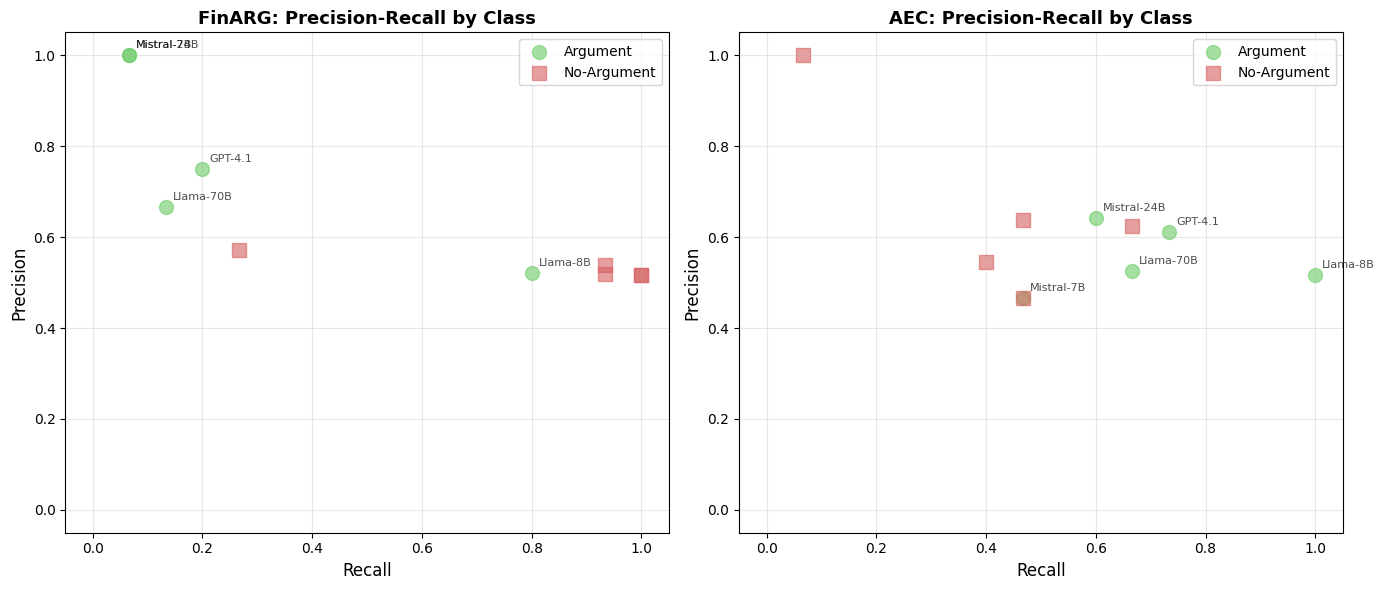


💡 Observation: Check if No-Argument points cluster at high recall → extreme bias


In [5]:
# Visualize precision-recall trade-off
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# FinARG
axes[0].scatter(finarg_metrics['Arg_Recall'], finarg_metrics['Arg_Precision'], 
                s=100, alpha=0.6, label='Argument', color='#6ACC65')
axes[0].scatter(finarg_metrics['NoArg_Recall'], finarg_metrics['NoArg_Precision'], 
                s=100, alpha=0.6, label='No-Argument', color='#D65F5F', marker='s')

for idx, row in finarg_metrics.iterrows():
    axes[0].annotate(row['Model'], (row['Arg_Recall'], row['Arg_Precision']), 
                     fontsize=8, alpha=0.7, xytext=(5, 5), textcoords='offset points')

axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('FinARG: Precision-Recall by Class', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(-0.05, 1.05)
axes[0].set_ylim(-0.05, 1.05)

# AEC
axes[1].scatter(aec_metrics['Arg_Recall'], aec_metrics['Arg_Precision'], 
                s=100, alpha=0.6, label='Argument', color='#6ACC65')
axes[1].scatter(aec_metrics['NoArg_Recall'], aec_metrics['NoArg_Precision'], 
                s=100, alpha=0.6, label='No-Argument', color='#D65F5F', marker='s')

for idx, row in aec_metrics.iterrows():
    axes[1].annotate(row['Model'], (row['Arg_Recall'], row['Arg_Precision']), 
                     fontsize=8, alpha=0.7, xytext=(5, 5), textcoords='offset points')

axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('AEC: Precision-Recall by Class', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(-0.05, 1.05)
axes[1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

print("\n💡 Observation: Check if No-Argument points cluster at high recall → extreme bias")

## 3. Sample-Level Analysis: What Do Arguments Look Like?

In [6]:
# Load sample-level predictions from Mistral-24B baseline
mistral_baseline = 'baseline_30_mistralai_Mistral-Small-24B-Instruct-2501'
mistral_data = results[mistral_baseline]

# Extract FinARG samples
finarg_samples = mistral_data['datasets']['FINARG']['samples']
aec_samples = mistral_data['datasets']['AEC']['samples']

print(f"\nFinARG: {len(finarg_samples)} samples")
print(f"AEC: {len(aec_samples)} samples")

# Analyze prediction patterns
def analyze_predictions(samples, dataset_name):
    """Analyze prediction patterns for a dataset."""
    df = pd.DataFrame(samples)
    
    # Confusion matrix
    confusion = pd.crosstab(df['true_label'], df['pred_original'], 
                            rownames=['True'], colnames=['Predicted'])
    
    print(f"\n=== {dataset_name}: Confusion Matrix ===")
    print(confusion)
    
    # Misclassified arguments (False Negatives)
    fn_samples = df[(df['true_label'] == 'Argument') & (df['pred_original'] == 'No-Argument')]
    print(f"\n❌ False Negatives (Arguments missed): {len(fn_samples)}")
    
    # Misclassified non-arguments (False Positives)
    fp_samples = df[(df['true_label'] == 'No-Argument') & (df['pred_original'] == 'Argument')]
    print(f"❌ False Positives (Non-arguments marked as arguments): {len(fp_samples)}")
    
    return df, fn_samples, fp_samples

finarg_df, finarg_fn, finarg_fp = analyze_predictions(finarg_samples, 'FinARG')
aec_df, aec_fn, aec_fp = analyze_predictions(aec_samples, 'AEC')


FinARG: 30 samples
AEC: 30 samples

=== FinARG: Confusion Matrix ===
Predicted    Argument  No-Argument
True                              
Argument            1           14
No-Argument         0           15

❌ False Negatives (Arguments missed): 14
❌ False Positives (Non-arguments marked as arguments): 0

=== AEC: Confusion Matrix ===
Predicted    Argument  No-Argument
True                              
Argument            9            6
No-Argument         5           10

❌ False Negatives (Arguments missed): 6
❌ False Positives (Non-arguments marked as arguments): 5


In [7]:
# Show examples of misclassified arguments in FinARG
print("\n" + "="*80)
print("=== FinARG: Examples of Missed Arguments (False Negatives) ===")
print("="*80)

for idx, row in finarg_fn.head(10).iterrows():
    print(f"\n[{row['id']}]")
    print(f"Sentence: {row['sentence']}")
    print(f"True: {row['true_label']} | Predicted: {row['pred_original']}")
    print("-" * 80)


=== FinARG: Examples of Missed Arguments (False Negatives) ===

[FINARG-train-1]
Sentence: So, on Instagram, there are a number of really exciting opportunities.
True: Argument | Predicted: No-Argument
--------------------------------------------------------------------------------

[FINARG-train-2]
Sentence: And so you can see the iPhone, the Mac, and the App Store adding, and with the iPad in PRC, not in Greater China, but in the PRC, iPad had its best quarter ever, higher than all the others, and also grew in a market that contracted for the overall market.
True: Argument | Predicted: No-Argument
--------------------------------------------------------------------------------

[FINARG-train-3]
Sentence: And I will actually combine these, because really those are fundamental driver that sits underneath this and then we can get to the specifics of end of support.
True: Argument | Predicted: No-Argument
--------------------------------------------------------------------------------



In [8]:
# Show examples of misclassified arguments in AEC
print("\n" + "="*80)
print("=== AEC: Examples of Missed Arguments (False Negatives) ===")
print("="*80)

for idx, row in aec_fn.head(10).iterrows():
    print(f"\n[{row['id']}]")
    print(f"Sentence: {row['sentence']}")
    print(f"True: {row['true_label']} | Predicted: {row['pred_original']}")
    print("-" * 80)


=== AEC: Examples of Missed Arguments (False Negatives) ===

[AEC-train-3]
Sentence: If your thinking of just taking the away guns in a confiscation.
True: Argument | Predicted: No-Argument
--------------------------------------------------------------------------------

[AEC-train-5]
Sentence: If you feel safe and moral with all of this, YOU are free to pay the $200 million your state spends on it annually.
True: Argument | Predicted: No-Argument
--------------------------------------------------------------------------------

[AEC-train-7]
Sentence: Firstly, sinjin is not a baboon.
True: Argument | Predicted: No-Argument
--------------------------------------------------------------------------------

[AEC-train-11]
Sentence: Firstly, I haven't posted any polls.
True: Argument | Predicted: No-Argument
--------------------------------------------------------------------------------

[AEC-train-12]
Sentence: If a man wants to marry multiple women, or a woman marry multiple men, that a

## 4. Text Characteristics: Are These Datasets Linguistically Different?

In [9]:
# Compare text characteristics across datasets
def compute_text_stats(samples):
    """Compute linguistic statistics for a dataset."""
    sentences = [s['sentence'] for s in samples]
    
    stats = {
        'mean_length_chars': np.mean([len(s) for s in sentences]),
        'mean_length_words': np.mean([len(s.split()) for s in sentences]),
        'std_length_words': np.std([len(s.split()) for s in sentences]),
        'median_length_words': np.median([len(s.split()) for s in sentences]),
        'max_length_words': max([len(s.split()) for s in sentences]),
    }
    
    return stats

# Compute for multiple datasets
text_stats = []
for dataset in ['ABSTRCT', 'AEC', 'FINARG', 'ARGUMINSCI', 'PE']:
    if dataset in mistral_data['datasets']:
        samples = mistral_data['datasets'][dataset]['samples']
        stats = compute_text_stats(samples)
        stats['Dataset'] = dataset
        text_stats.append(stats)

df_text_stats = pd.DataFrame(text_stats)
df_text_stats = df_text_stats[['Dataset', 'mean_length_words', 'std_length_words', 
                                'median_length_words', 'max_length_words']]

print("\n=== Text Length Characteristics ===")
print(df_text_stats.round(1).to_string(index=False))

# Highlight FinARG
finarg_row = df_text_stats[df_text_stats['Dataset'] == 'FINARG']
print("\n🔍 FinARG characteristics:")
print(finarg_row.to_string(index=False))


=== Text Length Characteristics ===
   Dataset  mean_length_words  std_length_words  median_length_words  max_length_words
   ABSTRCT               19.4              10.1                 18.5                45
       AEC               21.5              20.1                 16.5               106
    FINARG               21.4              15.2                 19.0                60
ARGUMINSCI               18.0              11.4                 16.5                64
        PE               17.2               6.8                 15.5                37

🔍 FinARG characteristics:
Dataset  mean_length_words  std_length_words  median_length_words  max_length_words
 FINARG          21.366667         15.153621                 19.0                60


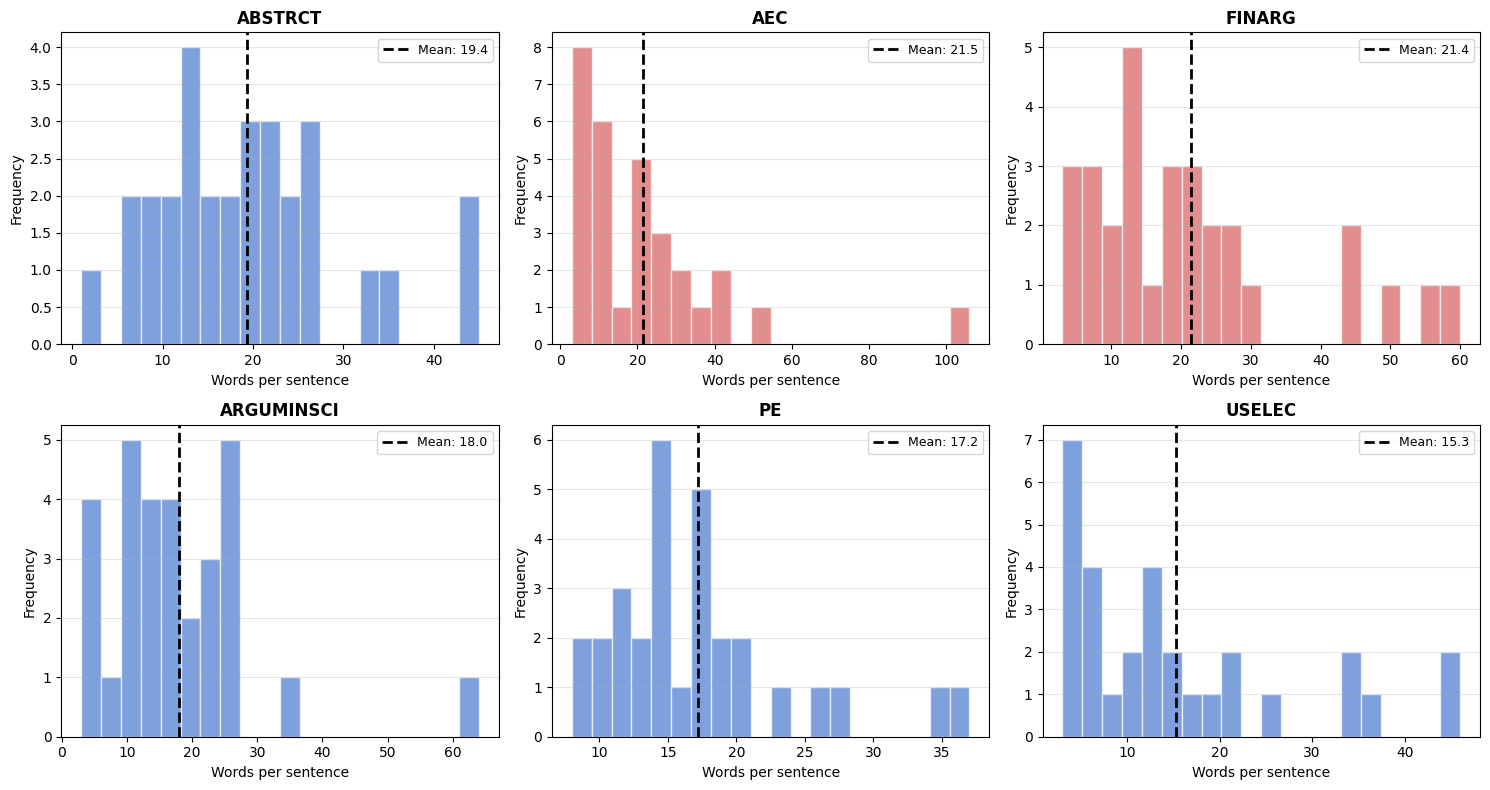

🔴 Red = FinARG & AEC
🔵 Blue = Other datasets


In [10]:
# Visualize sentence length distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

datasets_to_plot = ['ABSTRCT', 'AEC', 'FINARG', 'ARGUMINSCI', 'PE', 'USELEC']

for idx, dataset in enumerate(datasets_to_plot):
    if dataset not in mistral_data['datasets']:
        continue
    
    samples = mistral_data['datasets'][dataset]['samples']
    word_counts = [len(s['sentence'].split()) for s in samples]
    
    color = '#D65F5F' if dataset in ['FINARG', 'AEC'] else '#4878CF'
    
    axes[idx].hist(word_counts, bins=20, color=color, alpha=0.7, edgecolor='white')
    axes[idx].axvline(np.mean(word_counts), color='black', linestyle='--', linewidth=2, label=f'Mean: {np.mean(word_counts):.1f}')
    axes[idx].set_title(dataset, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Words per sentence', fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("🔴 Red = FinARG & AEC")
print("🔵 Blue = Other datasets")

## 5. Definition Analysis: Do the Definitions Make Sense?

In [11]:
# Load and display definitions
context_dir = Path('../../context')

def load_definition(dataset):
    """Load definition from context directory."""
    def_path = context_dir / dataset / 'definition.md'
    if def_path.exists():
        return def_path.read_text().strip()
    return "Not found"

finarg_def = load_definition('FINARG')
aec_def = load_definition('AEC')
abstrct_def = load_definition('ABSTRCT')  # For comparison

print("\n" + "="*80)
print("=== FinARG Definition ===")
print("="*80)
print(finarg_def)

print("\n" + "="*80)
print("=== AEC Definition ===")
print("="*80)
print(aec_def)

print("\n" + "="*80)
print("=== ABSTRCT Definition (for comparison - good performance) ===")
print("="*80)
print(abstrct_def)


=== FinARG Definition ===
An argument consists of a claim put forward by a speaker together with one or more premises that provide reasons, evidence, or justification for accepting that claim. The claim expresses the speaker’s standpoint or conclusion, while the premises support or, less commonly, attack it through an inferential relationship. Arguments are identified at the sentence or clause level and may involve multiple premises converging on a single claim, but each argument is treated as an independent micro-structure rather than part of a larger debate. Text is considered argumentative only when it involves such reasoning intended to justify or persuade, not merely to state facts. Non-argumentative text includes background information, explanations, descriptions, disclosures, repetitions, reformulations without new reasoning, or any statements that do not participate in an inference between a premise and a claim. Statements connected only by conjunctions, listings, or condition

In [12]:
# Analyze definition complexity
def definition_stats(definition, dataset_name):
    """Compute statistics about definition complexity."""
    words = definition.split()
    sentences = definition.split('. ')
    
    stats = {
        'Dataset': dataset_name,
        'Total words': len(words),
        'Total sentences': len(sentences),
        'Avg words/sentence': len(words) / len(sentences) if sentences else 0,
        'Contains "claim"': 'claim' in definition.lower(),
        'Contains "premise"': 'premise' in definition.lower(),
        'Contains "evidence"': 'evidence' in definition.lower(),
        'Contains "reasoning"': 'reasoning' in definition.lower(),
    }
    
    return stats

def_stats = [
    definition_stats(finarg_def, 'FINARG'),
    definition_stats(aec_def, 'AEC'),
    definition_stats(abstrct_def, 'ABSTRCT'),
]

df_def_stats = pd.DataFrame(def_stats)
print("\n=== Definition Characteristics ===")
print(df_def_stats.to_string(index=False))


=== Definition Characteristics ===
Dataset  Total words  Total sentences  Avg words/sentence  Contains "claim"  Contains "premise"  Contains "evidence"  Contains "reasoning"
 FINARG          161                7           23.000000              True                True                 True                  True
    AEC          168                6           28.000000              True               False                 True                  True
ABSTRCT          218                7           31.142857              True               False                 True                  True


## 6. Domain Analysis: What Domain Are These Datasets From?

In [13]:
# Analyze vocabulary/domain indicators
def extract_domain_keywords(samples, top_n=20):
    """Extract most frequent content words from samples."""
    # Combine all sentences
    all_text = ' '.join([s['sentence'].lower() for s in samples])
    
    # Simple tokenization and filtering
    words = re.findall(r'\b[a-z]{4,}\b', all_text)  # Words with 4+ chars
    
    # Common stopwords to exclude
    stopwords = {'that', 'this', 'with', 'from', 'have', 'been', 'were', 'will', 
                 'would', 'there', 'their', 'which', 'about', 'when', 'some', 'more',
                 'than', 'only', 'very', 'also', 'into', 'could', 'should', 'then'}
    
    words = [w for w in words if w not in stopwords]
    
    # Count and return top N
    counter = Counter(words)
    return counter.most_common(top_n)

# Extract for FinARG and AEC
finarg_keywords = extract_domain_keywords(finarg_samples)
aec_keywords = extract_domain_keywords(aec_samples)
abstrct_keywords = extract_domain_keywords(mistral_data['datasets']['ABSTRCT']['samples'])

print("\n=== FinARG: Top 20 Keywords ===")
for word, count in finarg_keywords:
    print(f"  {word:15s} {count:3d}")

print("\n=== AEC: Top 20 Keywords ===")
for word, count in aec_keywords:
    print(f"  {word:15s} {count:3d}")

print("\n=== ABSTRCT: Top 20 Keywords (for comparison) ===")
for word, count in abstrct_keywords:
    print(f"  {word:15s} {count:3d}")

print("\n💡 Domain hypothesis:")
print("   FinARG: Check for business/financial terminology")
print("   AEC: Check for online discussion/debate terminology")


=== FinARG: Top 20 Keywords ===
  really            7
  think             6
  where             4
  higher            3
  grew              3
  these             3
  both              3
  just              3
  terms             3
  value             3
  going             3
  people            3
  what              3
  seeing            3
  growth            3
  prime             3
  your              3
  amazon            3
  number            2
  adding            2

=== AEC: Top 20 Keywords ===
  they              6
  your              4
  what              4
  death             4
  think             3
  years             3
  gays              3
  laws              3
  executions        3
  murderer          3
  shall             3
  million           2
  change            2
  crime             2
  just              2
  people            2
  guilty            2
  need              2
  firstly           2
  plan              2

=== ABSTRCT: Top 20 Keywords (for comparison) ===
  pati

## 7. Cross-Dataset Comparison: Systematic Patterns?

In [14]:
# Create comprehensive comparison table
comparison_data = []

for dataset in ['ABSTRCT', 'AEC', 'FINARG', 'ARGUMINSCI', 'PE', 'USELEC']:
    if dataset not in mistral_data['datasets']:
        continue
    
    samples = mistral_data['datasets'][dataset]['samples']
    report = mistral_data['datasets'][dataset]['reports']['original']
    
    # Text stats
    text_stat = compute_text_stats(samples)
    
    # Performance stats
    arg_recall = report.get('Argument', {}).get('recall', 0)
    noarg_recall = report.get('No-Argument', {}).get('recall', 0)
    
    comparison_data.append({
        'Dataset': dataset,
        'Macro F1': report['macro avg']['f1-score'],
        'Accuracy': report['accuracy'],
        'Arg Recall': arg_recall,
        'NoArg Recall': noarg_recall,
        'Recall Gap': noarg_recall - arg_recall,
        'Avg Words': text_stat['mean_length_words'],
        'Max Words': text_stat['max_length_words'],
    })

df_comparison = pd.DataFrame(comparison_data).round(3)
df_comparison = df_comparison.sort_values('Macro F1')

print("\n" + "="*80)
print("=== Comprehensive Dataset Comparison (Mistral-24B) ===")
print("="*80)
print(df_comparison.to_string(index=False))

# Highlight problem datasets
print("\n🔴 Datasets with F1 < 0.5:")
print(df_comparison[df_comparison['Macro F1'] < 0.5][['Dataset', 'Macro F1', 'Recall Gap']].to_string(index=False))

print("\n🔴 Datasets with extreme recall gap (|gap| > 0.2):")
print(df_comparison[abs(df_comparison['Recall Gap']) > 0.2][['Dataset', 'Recall Gap', 'Arg Recall', 'NoArg Recall']].to_string(index=False))


=== Comprehensive Dataset Comparison (Mistral-24B) ===
   Dataset  Macro F1  Accuracy  Arg Recall  NoArg Recall  Recall Gap  Avg Words  Max Words
    FINARG     0.403     0.533       0.067         1.000       0.933     21.367         60
ARGUMINSCI     0.475     0.533       0.200         0.867       0.667     18.000         64
       AEC     0.633     0.633       0.600         0.667       0.067     21.533        106
   ABSTRCT     0.700     0.700       0.733         0.667      -0.067     19.400         45
        PE     0.729     0.733       0.600         0.867       0.267     17.200         37
    USELEC     0.729     0.733       0.600         0.867       0.267     15.333         46

🔴 Datasets with F1 < 0.5:
   Dataset  Macro F1  Recall Gap
    FINARG     0.403       0.933
ARGUMINSCI     0.475       0.667

🔴 Datasets with extreme recall gap (|gap| > 0.2):
   Dataset  Recall Gap  Arg Recall  NoArg Recall
    FINARG       0.933       0.067         1.000
ARGUMINSCI       0.667       0.2

## 8. Conclusions and Potential Scientific Findings

### Summary
Based on the analysis above, document the key findings:

1. **Performance gap**: Quantify how much worse FinARG/AEC are compared to other datasets
2. **Class bias pattern**: Describe the prediction bias (likely massive "No-Argument" bias)
3. **Domain characteristics**: Identify unique linguistic or domain features
4. **Definition issues**: Note if definitions are unclear or mismatched

### Potential Research Implications
- **Cross-domain generalization limits**: Models trained/prompted on general definitions fail on domain-specific argumentation
- **Definition transferability**: Some argument definitions don't transfer well to LLM zero-shot classification
- **Shortcut learning vs. genuine difficulty**: Is poor performance due to lack of lexical shortcuts, or genuinely hard annotation?

### Next Steps
1. Manually inspect 10-20 FinARG/AEC samples to verify annotation quality
2. Test if domain-adapted definitions improve performance
3. Check if adding examples (few-shot) helps more for these datasets
4. Investigate if contamination/leakage explains the pattern

In [15]:
# Summary statistics for writeup
print("\n" + "="*80)
print("=== KEY STATISTICS FOR THESIS ===")
print("="*80)

# FinARG
finarg_f1s = [np.mean(dataset_f1_scores['FINARG'])]
finarg_mean_recall_gap = finarg_metrics['Recall_Gap'].mean()
finarg_mean_arg_recall = finarg_metrics['Arg_Recall'].mean()

print(f"\nFinARG:")
print(f"  Mean F1 across models: {np.mean(dataset_f1_scores['FINARG']):.3f} (± {np.std(dataset_f1_scores['FINARG']):.3f})")
print(f"  Mean Argument recall: {finarg_mean_arg_recall:.3f}")
print(f"  Mean recall gap (NoArg - Arg): {finarg_mean_recall_gap:+.3f}")
print(f"  Interpretation: Models predict 'No-Argument' {abs(finarg_mean_recall_gap)*100:.1f}% more often than 'Argument'")

# AEC
aec_mean_recall_gap = aec_metrics['Recall_Gap'].mean()
aec_mean_arg_recall = aec_metrics['Arg_Recall'].mean()

print(f"\nAEC:")
print(f"  Mean F1 across models: {np.mean(dataset_f1_scores['AEC']):.3f} (± {np.std(dataset_f1_scores['AEC']):.3f})")
print(f"  Mean Argument recall: {aec_mean_arg_recall:.3f}")
print(f"  Mean recall gap (NoArg - Arg): {aec_mean_recall_gap:+.3f}")

# Compare to best-performing dataset
best_dataset = dataset_stats.iloc[-1]['Dataset']
best_f1 = dataset_stats.iloc[-1]['Mean F1']

print(f"\nComparison:")
print(f"  Best dataset: {best_dataset} (F1 = {best_f1:.3f})")
print(f"  FinARG gap: {best_f1 - np.mean(dataset_f1_scores['FINARG']):.3f} points lower")
print(f"  AEC gap: {best_f1 - np.mean(dataset_f1_scores['AEC']):.3f} points lower")


=== KEY STATISTICS FOR THESIS ===

FinARG:
  Mean F1 across models: 0.450 (± 0.043)
  Mean Argument recall: 0.253
  Mean recall gap (NoArg - Arg): +0.573
  Interpretation: Models predict 'No-Argument' 57.3% more often than 'Argument'

AEC:
  Mean F1 across models: 0.486 (± 0.086)
  Mean Argument recall: 0.693
  Mean recall gap (NoArg - Arg): -0.280

Comparison:
  Best dataset: ACQUA (F1 = 0.707)
  FinARG gap: 0.257 points lower
  AEC gap: 0.221 points lower
